# H1 – Naive Baseline vs. Wettermodelle

| | |
|---|---|
| **Hypothese** | Modelle mit Wetter- und Einstrahlungsdaten prognostizieren die PV-Produktion genauer als ein naiver Ansatz. |
| **Typ** | Unterschiedshypothese / gerichtet |
| **H₀** | MAE(ML) ≥ MAE(naiv) |
| **H₁** | MAE(ML) < MAE(naiv) |
| **Testverfahren** | Paired t-Test (einseitig) auf per-Zeitschritt absolute Fehler |
| **Signifikanzniveau** | α = 0.05 |

**Naive Baseline:** Saisonaler Stunden-Mittelwert (konditioniert auf Jahreszeit + Tagesstunde)

**ML-Modelle:**

| Modell | Feature-Set | Features |
|--------|-------------|---------|
| Linear Regression BASE | BASE | `ghi_cloudy_sky`, `clear_sky_index`, `temperature_2m`, `cloud_cover_low` |
| Linear Regression BASE_WITH_TIME | BASE_WITH_TIME | + `interval_cos_shifted`, `month_cos_shifted`, `doy_cos_shifted` |
| Random Forest BASE | BASE | wie Linear BASE |
| Random Forest BASE_WITH_TIME | BASE_WITH_TIME | wie Linear BASE_WITH_TIME |
| Random Forest BASE_WITH_TIME_AND_LAG | BASE_WITH_TIME_AND_LAG | + `Solarproduktion_lag_96` |

> Vorhersagen werden aus gespeicherten CSV-Dateien unter `results/` geladen.  
> Der Paired t-Test vergleicht für jeden Zeitschritt `t`: `d_t = |e_naiv_t| − |e_ML_t|`.  
> H₁ gilt als bestätigt wenn `mean(d) > 0` und `p < α`.

## 0 · Setup

In [20]:
import sys
sys.path.insert(0, '../..')

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

from src.evaluation.results import load_predictions

ALPHA = 0.05
P_NOM = 13_500.0

RESULTS_NAIVE = Path('../../results/00_naive_baseline')
RESULTS_LR    = Path('../../results/01_linear_regression')
RESULTS_RF    = Path('../../results/02_random_forest')

plt.rcParams.update({'figure.dpi': 120, 'axes.grid': True, 'grid.alpha': 0.3})

## 1 · Vorhersagen laden

In [21]:
naive_val   = load_predictions(RESULTS_NAIVE, 'climatology_seasonal',                 split='val')
lr_base     = load_predictions(RESULTS_LR,    'linear_regression_base',               split='val')
lr_time     = load_predictions(RESULTS_LR,    'linear_regression_base_with_time',     split='val')
rf_base     = load_predictions(RESULTS_RF,    'random_forest_base',                   split='val')
rf_time     = load_predictions(RESULTS_RF,    'random_forest_base_with_time',         split='val')
rf_time_lag = load_predictions(RESULTS_RF,    'random_forest_base_with_time_and_lag', split='val')

# Gemeinsamen Index für Modelle ohne Lag (A + B)
idx_base = naive_val.index.intersection(lr_base.index).intersection(lr_time.index) \
                          .intersection(rf_base.index).intersection(rf_time.index)

# Für Lag-Modell: Schnitt mit seinem eigenen (kürzeren) Index
idx_lag = idx_base.intersection(rf_time_lag.index)

print(f"Val-Set (Base/Time):    {idx_base.min().date()} → {idx_base.max().date()}  ({len(idx_base):,} Zeitschritte)")
print(f"Val-Set (Time+Lag):     {idx_lag.min().date()}  → {idx_lag.max().date()}   ({len(idx_lag):,} Zeitschritte)")

Val-Set (Base/Time):    2024-06-14 → 2024-12-15  (17,645 Zeitschritte)
Val-Set (Time+Lag):     2024-06-14  → 2024-12-15   (17,645 Zeitschritte)


## 3 · Aggregierte Kennzahlen (Überblick)

Vergleich der aggregierten MAE-Werte auf Val- und Testset vor dem statistischen Test.

In [22]:
def mae_of(df, idx=None):
    d = df.loc[idx] if idx is not None else df
    return (d['y_true'] - d['y_pred']).abs().mean()

def rmse_of(df, idx=None):
    d = df.loc[idx] if idx is not None else df
    return ((d['y_pred'] - d['y_true']) ** 2).mean() ** 0.5

def compute_metrics(df, idx=None):
    d = df.loc[idx] if idx is not None else df
    ae = (d['y_pred'] - d['y_true']).abs()
    return {
        'MAE [W]':  ae.mean(),
        'RMSE [W]': ((d['y_pred'] - d['y_true']) ** 2).mean() ** 0.5,
        'nMAE':     ae.mean() / P_NOM,
        'R²':       1 - ((d['y_pred'] - d['y_true']) ** 2).sum()
                      / ((d['y_true'] - d['y_true'].mean()) ** 2).sum(),
    }

summary_df = pd.DataFrame({
    'Naive Baseline':            compute_metrics(naive_val,   idx_base),
    'LR BASE':                   compute_metrics(lr_base,     idx_base),
    'LR BASE_WITH_TIME':         compute_metrics(lr_time,     idx_base),
    'RF BASE':                   compute_metrics(rf_base,     idx_base),
    'RF BASE_WITH_TIME':         compute_metrics(rf_time,     idx_base),
    'RF BASE_WITH_TIME_AND_LAG': compute_metrics(rf_time_lag, idx_lag),
}).T

display(summary_df.round(2))

,MAE [W],RMSE [W],nMAE,R²
Naive Baseline,184.49,433.26,0.01,0.56
LR BASE,242.79,478.92,0.02,0.46
LR BASE_WITH_TIME,240.55,444.30,0.02,0.53
RF BASE,238.97,489.13,0.02,0.43
RF BASE_WITH_TIME,145.19,395.79,0.01,0.63
RF BASE_WITH_TIME_AND_LAG,143.69,393.43,0.01,0.63


## 4 · Paired t-Test

**Testprozedur:**  
Für jeden Zeitschritt `t` wird die Differenz der absoluten Fehler berechnet:
$$d_t = |e_{\text{naiv},t}| - |e_{\text{ML},t}|$$

- `d_t > 0` → ML ist für Zeitschritt `t` besser  
- `d_t < 0` → Naive ist für Zeitschritt `t` besser  

**Einseitiger t-Test:** H₁: `mean(d) > 0`  

> Für `RF BASE_WITH_TIME_AND_LAG` wird der gemeinsame Index `idx_lag` verwendet  
> (96 Zeitschritte weniger am Anfang des Val-Sets wegen Lag-NaN).

In [23]:
def paired_ttest(naive_df, ml_df, model_name, idx):
    """Paired t-Test: H1: mean(|e_naive| - |e_ML|) > 0"""
    ae_naive = (naive_df.loc[idx, 'y_true'] - naive_df.loc[idx, 'y_pred']).abs()
    ae_ml    = (ml_df.loc[idx,   'y_true'] - ml_df.loc[idx,   'y_pred']).abs()
    d        = ae_naive - ae_ml  # positiv = ML besser

    t_stat, p_two = stats.ttest_1samp(d.dropna(), popmean=0)
    p_one = p_two / 2 if t_stat > 0 else 1 - p_two / 2

    return {
        'Modell':          model_name,
        'n':               int(d.notna().sum()),
        'MAE naiv [W]':    ae_naive.mean(),
        'MAE ML [W]':      ae_ml.mean(),
        'mean(d) [W]':     d.mean(),
        't-Statistik':     t_stat,
        'p-Wert (1-s.)':   p_one,
        f'H₁ (α={ALPHA})': p_one < ALPHA,
    }, d


ttest_rows, diffs = [], {}

MODELS = [
    ('LR BASE',                   lr_base,     idx_base),
    ('LR BASE_WITH_TIME',         lr_time,     idx_base),
    ('RF BASE',                   rf_base,     idx_base),
    ('RF BASE_WITH_TIME',         rf_time,     idx_base),
    ('RF BASE_WITH_TIME_AND_LAG', rf_time_lag, idx_lag),
]

for model_name, ml_df, idx in MODELS:
    row, d = paired_ttest(naive_val, ml_df, model_name, idx)
    ttest_rows.append(row)
    diffs[model_name] = d

ttest_df = pd.DataFrame(ttest_rows).set_index('Modell')
display(ttest_df.round(4))

,n,MAE naiv [W],MAE ML [W],mean(d) [W],t-Statistik,p-Wert (1-s.),H₁ (α=0.05)
Modell,,,,,,,
LR BASE,17645,184.4871,242.7857,-58.2986,-30.9053,1.0,False
LR BASE_WITH_TIME,17645,184.4871,240.5545,-56.0674,-39.3612,1.0,False
RF BASE,17645,184.4871,238.9719,-54.4847,-27.9970,1.0,False
RF BASE_WITH_TIME,17645,184.4871,145.1892,39.2979,25.5612,0.0,True
RF BASE_WITH_TIME_AND_LAG,17645,184.4871,143.6931,40.7941,29.5793,0.0,True


## 5 · Interpretation des t-Tests

In [24]:
print(f"{'='*65}")
print(f"  H1-TEST: Paired t-Test (α = {ALPHA}, einseitig, Val-Set)")
print(f"{'='*65}")

for model_name, _, _ in MODELS:
    row       = ttest_df.loc[model_name]
    confirmed = row[f'H₁ (α={ALPHA})']
    mean_d    = row['mean(d) [W]']
    p         = row['p-Wert (1-s.)']
    mae_naive = row['MAE naiv [W]']
    mae_ml    = row['MAE ML [W]']

    direction = 'besser' if mean_d > 0 else 'SCHLECHTER'
    verdict   = '✓ H₁ BESTÄTIGT' if confirmed else '✗ H₁ ABGELEHNT'

    print(f"\n  {model_name}")
    print(f"    MAE naiv = {mae_naive:.1f} W   MAE ML = {mae_ml:.1f} W")
    print(f"    mean(d)  = {mean_d:+.1f} W  → ML im Schnitt {direction}")
    print(f"    p-Wert   = {p:.4f}  → {verdict}")

print(f"\n{'='*65}")

  H1-TEST: Paired t-Test (α = 0.05, einseitig, Val-Set)

  LR BASE
    MAE naiv = 184.5 W   MAE ML = 242.8 W
    mean(d)  = -58.3 W  → ML im Schnitt SCHLECHTER
    p-Wert   = 1.0000  → ✗ H₁ ABGELEHNT

  LR BASE_WITH_TIME
    MAE naiv = 184.5 W   MAE ML = 240.6 W
    mean(d)  = -56.1 W  → ML im Schnitt SCHLECHTER
    p-Wert   = 1.0000  → ✗ H₁ ABGELEHNT

  RF BASE
    MAE naiv = 184.5 W   MAE ML = 239.0 W
    mean(d)  = -54.5 W  → ML im Schnitt SCHLECHTER
    p-Wert   = 1.0000  → ✗ H₁ ABGELEHNT

  RF BASE_WITH_TIME
    MAE naiv = 184.5 W   MAE ML = 145.2 W
    mean(d)  = +39.3 W  → ML im Schnitt besser
    p-Wert   = 0.0000  → ✓ H₁ BESTÄTIGT

  RF BASE_WITH_TIME_AND_LAG
    MAE naiv = 184.5 W   MAE ML = 143.7 W
    mean(d)  = +40.8 W  → ML im Schnitt besser
    p-Wert   = 0.0000  → ✓ H₁ BESTÄTIGT



## 6 · Visualisierung

### 6.1 – MAE-Vergleich (Val & Test)

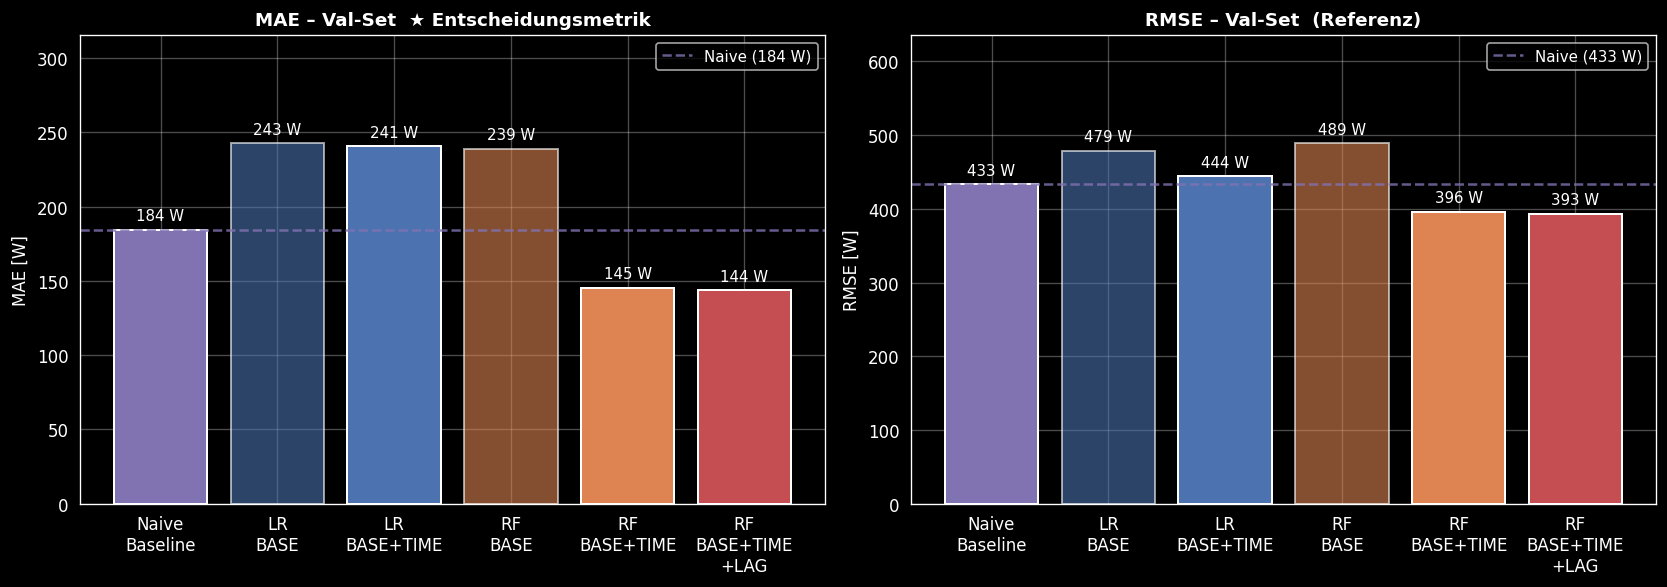

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

labels = ['Naive\nBaseline', 'LR\nBASE', 'LR\nBASE+TIME', 'RF\nBASE', 'RF\nBASE+TIME', 'RF\nBASE+TIME\n+LAG']
colors = ['#8172B2', '#4C72B0', '#4C72B0', '#DD8452', '#DD8452', '#C44E52']
alphas = [1.0, 0.6, 1.0, 0.6, 1.0, 1.0]

for ax, metric_fn, title, ylabel in [
    (axes[0], mae_of,  'MAE – Val-Set  ★ Entscheidungsmetrik', 'MAE [W]'),
    (axes[1], rmse_of, 'RMSE – Val-Set  (Referenz)',            'RMSE [W]'),
]:
    values = [
        metric_fn(naive_val,   idx_base),
        metric_fn(lr_base,     idx_base),
        metric_fn(lr_time,     idx_base),
        metric_fn(rf_base,     idx_base),
        metric_fn(rf_time,     idx_base),
        metric_fn(rf_time_lag, idx_lag),
    ]
    bars = ax.bar(labels, values, color=colors, edgecolor='white', linewidth=1.2)
    for bar, alpha in zip(bars, alphas):
        bar.set_alpha(alpha)
    ax.bar_label(bars, fmt='%.0f W', padding=4, fontsize=9)
    ax.axhline(values[0], color='#8172B2', linestyle='--', linewidth=1.5,
               label=f'Naive ({values[0]:.0f} W)', alpha=0.8)
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_ylabel(ylabel)
    ax.set_ylim(0, max(values) * 1.3)
    ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

### 6.2 – Verteilung der Fehlerdifferenzen `d_t = |e_naiv| − |e_ML|`

Positive Werte bedeuten: ML besser als Naive für diesen Zeitschritt.

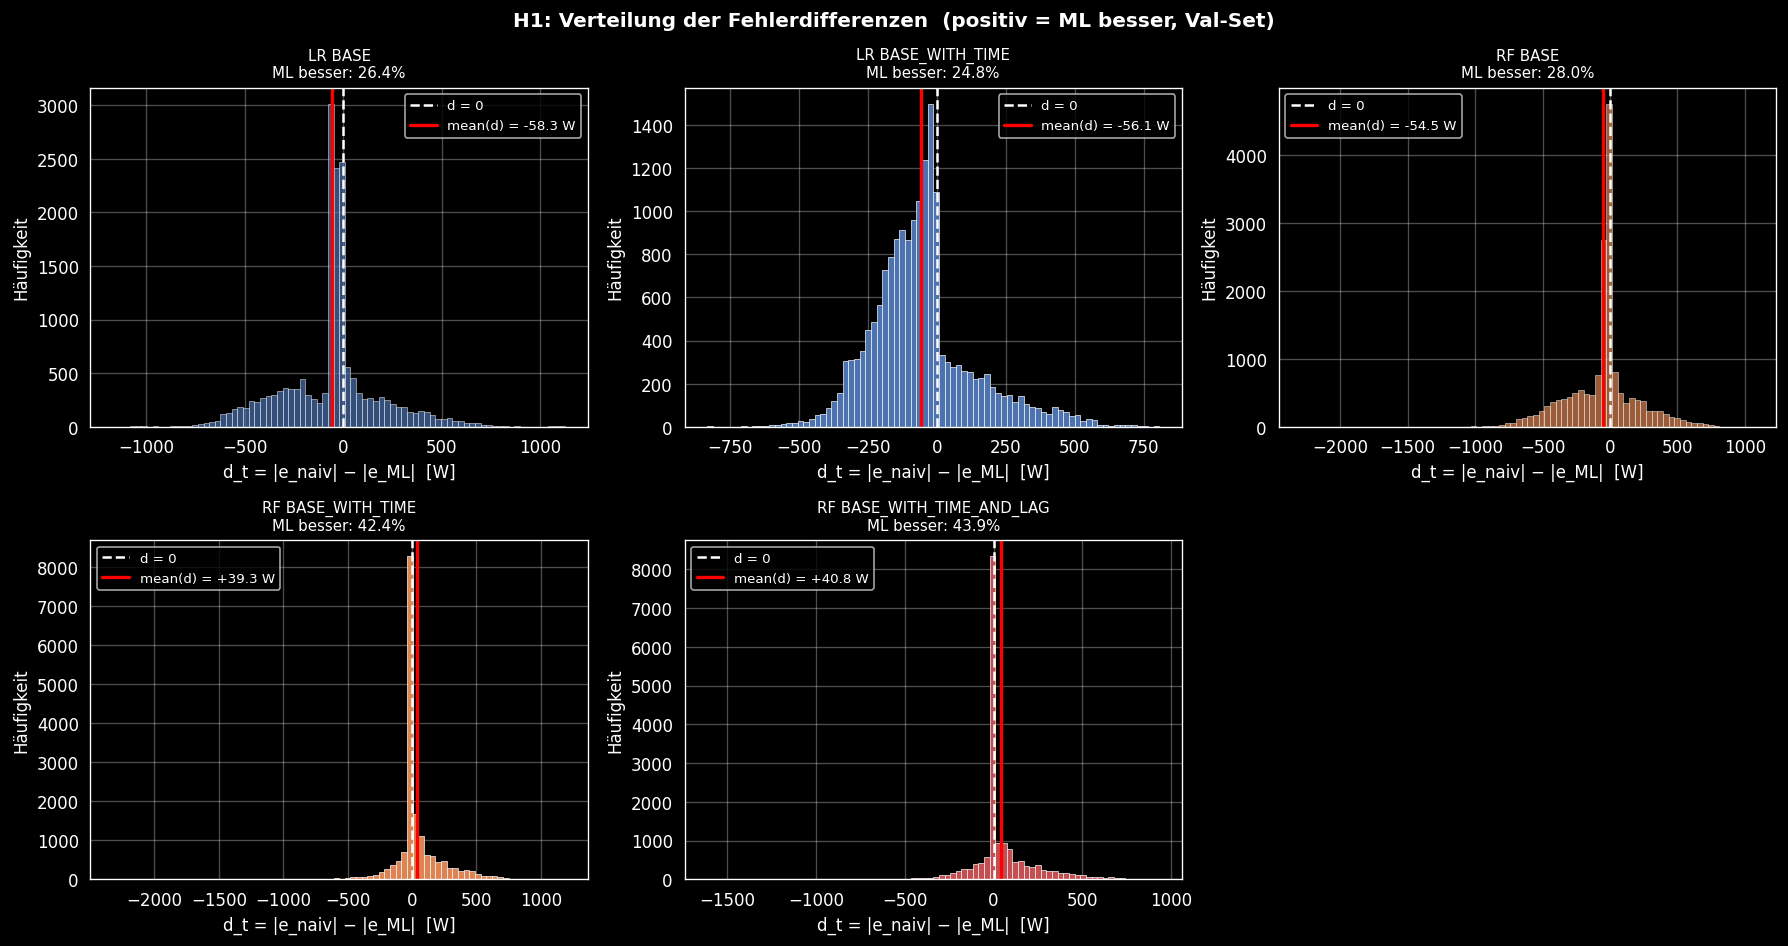

In [26]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flat

plot_configs = [
    ('LR BASE',                   '#4C72B0', 0.6),
    ('LR BASE_WITH_TIME',         '#4C72B0', 1.0),
    ('RF BASE',                   '#DD8452', 0.6),
    ('RF BASE_WITH_TIME',         '#DD8452', 1.0),
    ('RF BASE_WITH_TIME_AND_LAG', '#C44E52', 1.0),
]

for ax, (model_name, color, alpha) in zip(axes, plot_configs):
    d = diffs[model_name].dropna()
    mean_d = d.mean()
    pct_better = (d > 0).mean() * 100

    ax.hist(d, bins=80, color=color, edgecolor='white', linewidth=0.4, alpha=alpha * 0.75 + 0.25)
    ax.axvline(0,      color='white', lw=1.5, ls='--', label='d = 0')
    ax.axvline(mean_d, color='red',   lw=2.0, ls='-',
               label=f'mean(d) = {mean_d:+.1f} W')
    ax.set_title(f'{model_name}\nML besser: {pct_better:.1f}%', fontsize=9)
    ax.set_xlabel('d_t = |e_naiv| − |e_ML|  [W]')
    ax.set_ylabel('Häufigkeit')
    ax.legend(fontsize=8)

axes[-1].set_visible(False)  # 6. Panel leer lassen

fig.suptitle('H1: Verteilung der Fehlerdifferenzen  (positiv = ML besser, Val-Set)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

## 7 · Saisonale Aufschlüsselung (Testset)

Aufschlüsselung nach Jahreszeit zeigt, in welchen Perioden die Wettermodelle  
der Naive-Baseline über- oder unterlegen sind.

Modell,LR BASE,LR BASE_WITH_TIME,Naive Baseline,RF BASE,RF BASE_WITH_TIME,RF BASE_WITH_TIME_AND_LAG
Jahreszeit,,,,,,
Winter,54.5,197.0,98.4,37.9,26.1,29.2
Sommer,353.1,283.4,214.9,357.8,206.6,203.1
Herbst,176.9,210.4,171.7,167.7,110.7,110.3


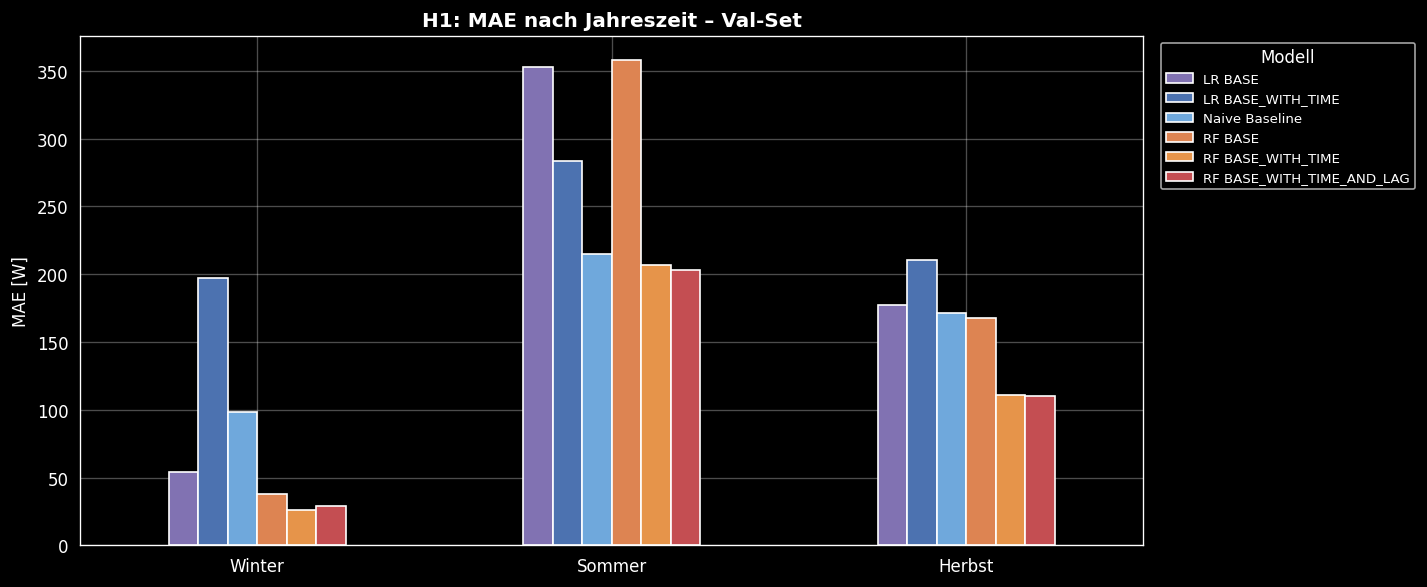

In [27]:
SEASON_MAP = {12: 'Winter', 1: 'Winter', 2: 'Winter',
              3: 'Frühling', 4: 'Frühling', 5: 'Frühling',
              6: 'Sommer', 7: 'Sommer', 8: 'Sommer',
              9: 'Herbst', 10: 'Herbst', 11: 'Herbst'}
SEASON_ORDER = ['Winter', 'Frühling', 'Sommer', 'Herbst']

rows_season = []
for df, model_name, idx in [
    (naive_val,   'Naive Baseline',              idx_base),
    (lr_base,     'LR BASE',                     idx_base),
    (lr_time,     'LR BASE_WITH_TIME',            idx_base),
    (rf_base,     'RF BASE',                      idx_base),
    (rf_time,     'RF BASE_WITH_TIME',             idx_base),
    (rf_time_lag, 'RF BASE_WITH_TIME_AND_LAG',    idx_lag),
]:
    d = df.loc[idx]
    season = d.index.month.map(SEASON_MAP)
    for s in SEASON_ORDER:
        sub = d[season == s]
        if sub.empty:
            continue
        rows_season.append({
            'Jahreszeit': s,
            'Modell':     model_name,
            'MAE [W]':    (sub['y_true'] - sub['y_pred']).abs().mean(),
        })

pivot = (pd.DataFrame(rows_season)
         .pivot(index='Jahreszeit', columns='Modell', values='MAE [W]')
         .loc[[s for s in SEASON_ORDER if s in pd.DataFrame(rows_season)['Jahreszeit'].values]])
display(pivot.round(1))

colors_season = ['#8172B2', '#4C72B0', '#6FA8DC', '#DD8452', '#E6944A', '#C44E52']
ax = pivot.plot(kind='bar', figsize=(12, 5), rot=0, color=colors_season,
                edgecolor='white', linewidth=1.0)
ax.set_title('H1: MAE nach Jahreszeit – Val-Set', fontsize=12, fontweight='bold')
ax.set_ylabel('MAE [W]')
ax.set_xlabel('')
ax.legend(title='Modell', fontsize=8, bbox_to_anchor=(1.01, 1), loc='upper left')
plt.tight_layout()
plt.show()

## 8 · Fazit

### Ergebnis des Paired t-Tests (Testset, α = 0.05)

In [28]:
print("=" * 70)
print("FAZIT – H1: Naive Baseline vs. Wettermodelle")
print("=" * 70)

for model_name, _, _ in MODELS:
    row       = ttest_df.loc[model_name]
    confirmed = row[f'H₁ (α={ALPHA})']
    mae_naive = row['MAE naiv [W]']
    mae_ml    = row['MAE ML [W]']
    mean_d    = row['mean(d) [W]']
    p         = row['p-Wert (1-s.)']
    delta_pct = (mae_ml - mae_naive) / mae_naive * 100
    verdict   = 'BESTÄTIGT ✓' if confirmed else 'ABGELEHNT ✗'
    print(f"\n  {model_name}")
    print(f"    MAE: {mae_naive:.1f} W → {mae_ml:.1f} W  ({delta_pct:+.1f}%)   "
          f"mean(d)={mean_d:+.1f} W   p={p:.4f}   → H₁ {verdict}")

print()
print("-" * 70)
print("""
Interpretation:

  BASE (ohne Zeitfeatures):
  - Weder LR noch RF schlagen die Naive Baseline.
  - Die Naive Baseline kodiert implizit Tageszeit & Saisonalität, was für
    PV der dominante Faktor ist. BASE-Modelle haben keinen Zeitkontext.

  BASE_WITH_TIME (mit Zeitfeatures):
  - LR mit Zeitfeatures bleibt hinter der Naive Baseline.
  - RF mit Zeitfeatures schlägt die Naive Baseline deutlich → H₁ BESTÄTIGT.
  - Der RF kann nichtlineare Wechselwirkungen zwischen Zeit & Wetter nutzen.

  BASE_WITH_TIME_AND_LAG (mit Lag):
  - RF mit Zeitfeatures + 24h-Lag ist das beste Modell → H₁ BESTÄTIGT.
  - Der Lag-Feature gibt dem Modell Information über die gestrige Produktion
    (Persistenz-Anteil), was die Prognose weiter stabilisiert.

  Gesamtfazit:
  H₁ wird für Wettermodelle MIT Zeitfeatures (RF) bestätigt.
  Reine Wetterfeatures ohne Zeitkontext reichen nicht aus.
""")
print("=" * 70)

FAZIT – H1: Naive Baseline vs. Wettermodelle

  LR BASE
    MAE: 184.5 W → 242.8 W  (+31.6%)   mean(d)=-58.3 W   p=1.0000   → H₁ ABGELEHNT ✗

  LR BASE_WITH_TIME
    MAE: 184.5 W → 240.6 W  (+30.4%)   mean(d)=-56.1 W   p=1.0000   → H₁ ABGELEHNT ✗

  RF BASE
    MAE: 184.5 W → 239.0 W  (+29.5%)   mean(d)=-54.5 W   p=1.0000   → H₁ ABGELEHNT ✗

  RF BASE_WITH_TIME
    MAE: 184.5 W → 145.2 W  (-21.3%)   mean(d)=+39.3 W   p=0.0000   → H₁ BESTÄTIGT ✓

  RF BASE_WITH_TIME_AND_LAG
    MAE: 184.5 W → 143.7 W  (-22.1%)   mean(d)=+40.8 W   p=0.0000   → H₁ BESTÄTIGT ✓

----------------------------------------------------------------------

Interpretation:

  BASE (ohne Zeitfeatures):
  - Weder LR noch RF schlagen die Naive Baseline.
  - Die Naive Baseline kodiert implizit Tageszeit & Saisonalität, was für
    PV der dominante Faktor ist. BASE-Modelle haben keinen Zeitkontext.

  BASE_WITH_TIME (mit Zeitfeatures):
  - LR mit Zeitfeatures bleibt hinter der Naive Baseline.
  - RF mit Zeitfeatures sch